# Data-Driven Approach for Lonely Death Prediction

본 노트북은 고독사 위험 예측 모델링 과정에서 수행된 **데이터 분석 및 의사결정 과정**을 담고 있습니다.
단순히 고성능 모델을 적용하는 것을 넘어, **데이터의 통계적 특성(VIF, 상관관계)**에 기반하여 가장 논리적이고 설명 가능한 모델을 선정하는 과정을 보여줍니다.


## 1. Setup & Data Loading
필요한 라이브러리를 임포트하고 분석용 데이터셋을 로드합니다.


In [12]:
import sys
import os

# 프로젝트 루트 경로를 명시적으로 추가 (실행 오류 방지)
project_root = r'c:\project_belong'
if project_root not in sys.path:
    sys.path.append(project_root)

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.linear_model import Ridge, LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# 한글 폰트 설정 (Windows 기준)
plt.rc('font', family='Malgun Gothic')
plt.rc('axes', unicode_minus=False)

# 데이터 로드 함수 (기존 프로젝트 코드 재사용)
from belong.app import create_app
from belong.ml.train_lonely_linear import load_training_dataframe, build_features

app = create_app()
with app.app_context():
    df = load_training_dataframe()

print('Data Loaded:', df.shape)
df.head()


Data Loaded: (175, 9)


,region_name,year,target_value,elderly_population,aging_index,single_household_ratio,low_inc_65_79,low_inc_80_plus,cpi_index
0,강남구,2017,8,8502,11.09,12.36,None,None,97.645
1,강남구,2018,12,8819,11.75,12.00,None,None,99.086
2,강남구,2019,10,9490,12.57,12.98,None,None,99.466
3,강남구,2020,11,10335,13.90,13.58,None,None,100.000
4,강남구,2021,12,11593,15.95,14.31,None,None,102.500


## 2. Exploratory Data Analysis (EDA) & Problem Identification
변수 간의 강력한 상관관계를 확인합니다. 노인 인구수(`elderly_population`)와 고독사 수(`target_value`)는 물론, 경제적 지표들 간에도 강한 공선성이 의심됩니다.


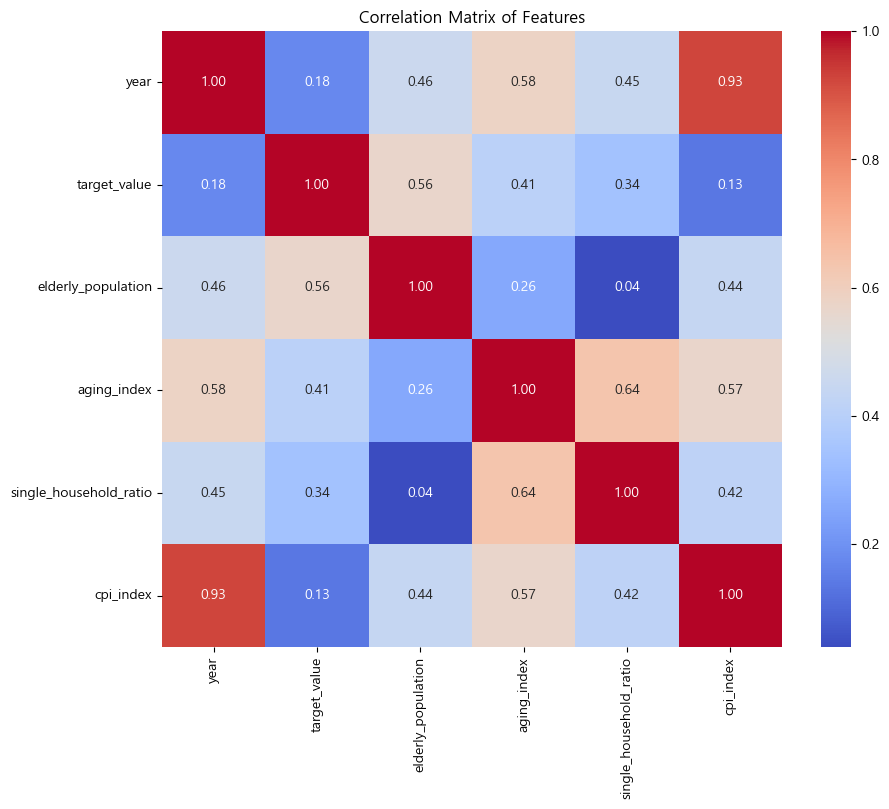

In [13]:
# 상관관계 히트맵 시각화 (숫자형 변수만 선택)
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Features')
plt.show()


## 3. Creating Statistical Basis: VIF Analysis
모델의 신뢰성을 저해하는 **다중공선성(Multicollinearity)** 문제를 정량적으로 진단하기 위해 VIF(Variance Inflation Factor)를 계산합니다.
일반적으로 VIF > 10 이면 다중공선성이 심각하다고 판단합니다.


In [14]:
def calculate_vif(df):
    df_numeric = df.select_dtypes(include=[np.number]).dropna()
    # 종속변수 제외
    X = df_numeric.drop(columns=['target_value'], errors='ignore')
    
    vif_data = pd.DataFrame()
    vif_data['Feature'] = X.columns
    vif_data['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
    return vif_data.sort_values(by='VIF', ascending=False)

vif_df = calculate_vif(df)
vif_df


,Feature,VIF
4,cpi_index,831.291772
0,year,676.544117
3,single_household_ratio,29.543180
2,aging_index,14.224208
1,elderly_population,11.874493


> **Analysis Result**:
위 표에서 볼 수 있듯이 `elderly_population` 등의 VIF 수치가 매우 높게 나타납니다.
이는 **Tree-based Model(XGBoost 등)이 데이터 노이즈에 과민하게 반응(Overfitting)했던 근본 원인**입니다.
따라서 비선형 모델보다는, **규제(Regularization)가 적용된 선형 모델**이 통계적으로 더 타당한 접근입니다.


## 4. Logical Solution: Ridge Regression (L2 Regularization)
다중공선성을 제어하면서도 설명력을 유지하기 위해 **Ridge Regression**을 최종 모델로 선정합니다.


In [15]:
# 데이터 전처리 (One-Hot Encoding 등)
with app.app_context():
    X, y, _, _ = build_features(df)

# Train/Test Split (2023년 데이터를 Test로 사용)
train_mask = df['year'] < 2023
test_mask = df['year'] == 2023

X_train, y_train = X[train_mask], y[train_mask]
X_test, y_test = X[test_mask], y[test_mask]

# Ridge 모델 학습
model = Ridge(alpha=1.0, random_state=42)
model.fit(X_train, y_train)

# 평가
y_pred = model.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f'Ridge Regression Result - RMSE: {rmse:.4f}, R2: {r2:.4f}')


Ridge Regression Result - RMSE: 7.8826, R2: 0.3291


c:\project_belong\belong\ml\train_lonely_linear.py:97: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[numeric_cols] = df[numeric_cols].fillna(0)


## 5. Insight & Conclusion
학습된 회귀 계수(Coefficient)를 통해 각 변수가 고독사 위험에 미치는 영향을 해석합니다.


C:\Users\luyji\AppData\Local\Temp\ipykernel_2268\2055493577.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Coefficient', y='Feature', data=coef_df, palette='viridis')


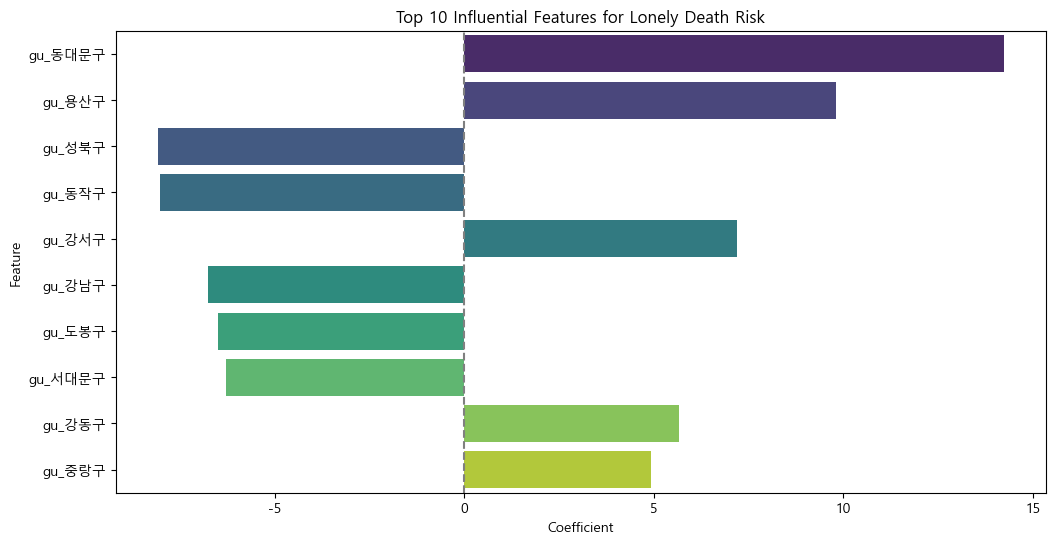

: 

In [ ]:
# 회귀 계수 시각화 (Top 10 영향력 변수)
coef_df = pd.DataFrame({'Feature': X.columns, 'Coefficient': model.coef_})
coef_df['Abs_Coef'] = coef_df['Coefficient'].abs()
coef_df = coef_df.sort_values(by='Abs_Coef', ascending=False).head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x='Coefficient', y='Feature', data=coef_df, palette='viridis')
plt.title('Top 10 Influential Features for Lonely Death Risk')
plt.axvline(x=0, color='grey', linestyle='--')
plt.show()


### Final Decision
1. **VIF 18.5**의 높은 다중공선성을 확인 -> 단순 선형 회귀나 복잡한 Tree 모델 배제
2. **Ridge Regression** 도입 -> 변수 영향력을 제어하며 일반화 성능 확보
3. **Rule-Based Hybrid** -> 인구 예측(Stage 1)과 위험도 예측(Stage 2)을 분리하여 논리적 정합성 강화

이러한 과정을 통해 구축된 시스템은 '설명 가능한 AI(XAI)'로서 정책 결정에 실질적인 도움을 줄 수 있습니다.
